# Airline Passenger Satisfaction - Advanced Machine Learning Pipeline
# Author: Pedro M.
# Enhanced modeling with multiple algorithms, hyperparameter optimization, and interpretability

# 🤖 Airline Passenger Satisfaction - Advanced ML Modeling
# 
# ## 📋 Table of Contents
# 1. [Setup & Configuration](#1-setup--configuration)
# 2. [Data Preparation](#2-data-preparation)
# 3. [Feature Engineering & Selection](#3-feature-engineering--selection)
# 4. [Model Development](#4-model-development)
# 5. [Hyperparameter Optimization](#5-hyperparameter-optimization)
# 6. [Model Evaluation & Comparison](#6-model-evaluation--comparison)
# 7. [Model Interpretability](#7-model-interpretability)
# 8. [Final Model & Production Pipeline](#8-final-model--production-pipeline)

## 1. Setup & Configuration

In [1]:
# Core libraries
import numpy as np
import pandas as pd
import warnings
import os
import pickle
import json
from datetime import datetime
import time
from typing import Dict, List, Tuple, Any
import joblib

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Machine Learning
from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold, 
    GridSearchCV, RandomizedSearchCV, cross_validate
)
from sklearn.preprocessing import StandardScaler, LabelEncoder, RobustScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score,
    make_scorer
)
from sklearn.feature_selection import (
    SelectKBest, f_classif, mutual_info_classif,
    RFE, SelectFromModel
)
from sklearn.decomposition import PCA
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    VotingClassifier, StackingClassifier, AdaBoostClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

# Advanced ML libraries
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

# Model interpretation
import shap
import eli5
from eli5.sklearn import PermutationImportance

# Hyperparameter optimization
from hyperopt import hp, fmin, tpe, Trials, STATUS_OK
import optuna

# Utilities
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

In [2]:
# Configuration
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
np.random.seed(42)

# Plotting style
plt.style.use('seaborn-v0_8-darkgrid')
COLORS = {
    'primary': '#667eea',
    'secondary': '#764ba2',
    'success': '#4caf50',
    'warning': '#ff9800',
    'danger': '#f44336',
    'info': '#2196f3'
}

print("✅ All libraries imported successfully")
print(f"📅 Modeling Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

# Create directories for outputs
os.makedirs('models', exist_ok=True)
os.makedirs('results', exist_ok=True)
os.makedirs('plots', exist_ok=True)

✅ All libraries imported successfully
📅 Modeling Date: 2025-06-04 14:56:34


## 2. Data Loading

In [3]:
# Load data
train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')

print(f"📊 Data loaded successfully!")
print(f"Training set: {train_df.shape}")
print(f"Test set: {test_df.shape}")

# Display first few rows
train_df.head()

📊 Data loaded successfully!
Training set: (103904, 25)
Test set: (25976, 25)


,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,5,3,5,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,3,1,3,1,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,2,5,5,5,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,5,2,2,2,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,3,4,5,5,3,3,4,4,3,3,3,0,0.0,satisfied


In [4]:
# Check columns and data types
print("📋 Column Information:")
print(train_df.info())

# Check for missing values
print("\n❓ Missing Values:")
missing_train = train_df.isnull().sum()
if missing_train.sum() > 0:
    print(missing_train[missing_train > 0])
else:
    print("No missing values found!")

📋 Column Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         103904 non-null  int64  
 1   id                                 103904 non-null  int64  
 2   Gender                             103904 non-null  object 
 3   Customer Type                      103904 non-null  object 
 4   Age                                103904 non-null  int64  
 5   Type of Travel                     103904 non-null  object 
 6   Class                              103904 non-null  object 
 7   Flight Distance                    103904 non-null  int64  
 8   Inflight wifi service              103904 non-null  int64  
 9   Departure/Arrival time convenient  103904 non-null  int64  
 10  Ease of Online booking             103904 non-null  int64  
 11  Gate location    

## 4. Feature Engineering

In [44]:
def create_features(df):
    """
    Create engineered features from existing ones
    """
    df_new = df.copy()

    # Service-related features
    service_cols = [col for col in df.columns if any(
        keyword in col.lower() for keyword in ['service', 'comfort', 'cleanliness', 'entertainment', 'food']
    ) and col in df.columns]

    if service_cols:
        print(f"📊 Creating features from {len(service_cols)} service columns...")

        df_new['avg_service_rating'] = df[service_cols].mean(axis=1)
        df_new['min_service_rating'] = df[service_cols].min(axis=1)
        df_new['max_service_rating'] = df[service_cols].max(axis=1)
        df_new['service_rating_std'] = df[service_cols].std(axis=1)
        df_new['low_rating_count'] = (df[service_cols] <= 2).sum(axis=1)
        df_new['high_rating_count'] = (df[service_cols] >= 4).sum(axis=1)

    # Delay features
    if 'Departure Delay in Minutes' in df.columns and 'Arrival Delay in Minutes' in df.columns:
        print("✈️ Creating delay features...")
        df_new['total_delay'] = df['Departure Delay in Minutes'] + df['Arrival Delay in Minutes']
        df_new['delay_difference'] = df['Arrival Delay in Minutes'] - df['Departure Delay in Minutes']
        df_new['is_delayed'] = (df_new['total_delay'] > 15).astype(int)
        df_new['severe_delay'] = (df_new['total_delay'] > 60).astype(int)

    # Age features
    if 'Age' in df.columns:
        print("👤 Creating age features...")
        df_new['age_squared'] = df['Age'] ** 2
        df_new['is_senior'] = (df['Age'] >= 60).astype(int)
        df_new['is_young'] = (df['Age'] <= 25).astype(int)
        df_new['age_group'] = pd.cut(df['Age'], 
                                     bins=[0, 25, 40, 60, 100], 
                                     labels=['Young', 'Adult', 'Middle', 'Senior'])

    # Distance features
    if 'Flight Distance' in df.columns:
        print("📏 Creating distance features...")
        df_new['log_distance'] = np.log1p(df['Flight Distance'])
        df_new['is_long_flight'] = (df['Flight Distance'] > 1000).astype(int)

        try:
            df_new['distance_category'] = pd.qcut(df['Flight Distance'],
                                                  q=4,
                                                  labels=['Short', 'Medium', 'Long', 'Very Long'],
                                                  duplicates='drop')
        except ValueError as e:
            print(f"⚠️ Could not create distance_category: {e}")
            df_new['distance_category'] = 'Unknown'

    print(f"✅ Created {len(df_new.columns) - len(df.columns)} new features")

    return df_new

# Apply feature engineering
print("\n🔧 Engineering features...")
train_df_eng = create_features(train_df)
test_df_eng = create_features(test_df)


🔧 Engineering features...
📊 Creating features from 9 service columns...
✈️ Creating delay features...
👤 Creating age features...
📏 Creating distance features...
✅ Created 17 new features
📊 Creating features from 9 service columns...
✈️ Creating delay features...
👤 Creating age features...
📏 Creating distance features...
✅ Created 17 new features


In [31]:
# Identify columns to remove (non-features)
remove_cols = ['Unnamed: 0', 'id', 'satisfaction']
remove_cols = [col for col in remove_cols if col in train_df.columns]

print(f"🗑️ Removing columns: {remove_cols}")

# Separate features and target
target_col = 'satisfaction'
feature_cols = [col for col in train_df.columns if col not in remove_cols + [target_col]]

print(f"\n📊 Number of features: {len(feature_cols)}")

# Create target variable
y = (train_df[target_col] == 'satisfied').astype(int)
print(f"\n🎯 Target distribution:")
print(y.value_counts(normalize=True))


🗑️ Removing columns: ['Unnamed: 0', 'id', 'satisfaction']

📊 Number of features: 22

🎯 Target distribution:
satisfaction
0    0.566667
1    0.433333
Name: proportion, dtype: float64


 ## 4. Data Preprocessing

In [32]:
# Identify columns
print("\n🎯 Preparing data for modeling...")

# Define columns to remove (non-features)
non_feature_cols = ['Unnamed: 0', 'id', 'satisfaction']
non_feature_cols = [col for col in non_feature_cols if col in train_df_eng.columns]

# Get feature columns
feature_cols = [col for col in train_df_eng.columns if col not in non_feature_cols + ['satisfaction']]

print(f"📊 Total features: {len(feature_cols)}")

# Separate features and target
X = train_df_eng[feature_cols].copy()
y = (train_df_eng['satisfaction'] == 'satisfied').astype(int)

X_test = test_df_eng[feature_cols].copy()

print(f"\n✅ Data shapes:")
print(f"   X_train: {X.shape}")
print(f"   X_test: {X_test.shape}")
print(f"   y_train: {y.shape}")

print(f"\n🎯 Target distribution:")
print(y.value_counts(normalize=True))


🎯 Preparing data for modeling...
📊 Total features: 39

✅ Data shapes:
   X_train: (103904, 39)
   X_test: (25976, 39)
   y_train: (103904,)

🎯 Target distribution:
satisfaction
0    0.566667
1    0.433333
Name: proportion, dtype: float64


In [33]:
# Handle categorical variables
print("\n🔄 Encoding categorical variables...")

# Find categorical columns
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Found {len(categorical_cols)} categorical columns: {categorical_cols}")

# Create label encoders
label_encoders = {}

for col in categorical_cols:
    print(f"\nEncoding '{col}'...")
    le = LabelEncoder()
    
    # Get all unique values from both train and test
    all_values = pd.concat([X[col], X_test[col]]).dropna().unique()
    print(f"  Unique values: {all_values}")
    
    # Fit encoder
    le.fit(all_values)
    
    # Transform train data
    X[col] = X[col].map(lambda x: le.transform([x])[0] if pd.notna(x) and x in le.classes_ else -1)
    
    # Transform test data
    X_test[col] = X_test[col].map(lambda x: le.transform([x])[0] if pd.notna(x) and x in le.classes_ else -1)
    
    # Store encoder
    label_encoders[col] = le
    
    print(f"  ✅ Encoded successfully")

# Verify all columns are numeric
remaining_categorical = X.select_dtypes(include=['object', 'category']).columns.tolist()
if remaining_categorical:
    print(f"\n❌ Warning: Still have categorical columns: {remaining_categorical}")
else:
    print("\n✅ All categorical columns encoded successfully!")


🔄 Encoding categorical variables...
Found 6 categorical columns: ['Gender', 'Customer Type', 'Type of Travel', 'Class', 'age_group', 'distance_category']

Encoding 'Gender'...
  Unique values: ['Male' 'Female']
  ✅ Encoded successfully

Encoding 'Customer Type'...
  Unique values: ['Loyal Customer' 'disloyal Customer']
  ✅ Encoded successfully

Encoding 'Type of Travel'...
  Unique values: ['Personal Travel' 'Business travel']
  ✅ Encoded successfully

Encoding 'Class'...
  Unique values: ['Eco Plus' 'Business' 'Eco']
  ✅ Encoded successfully

Encoding 'age_group'...
  Unique values: ['Young', 'Adult', 'Senior', 'Middle']
Categories (4, object): ['Young' < 'Adult' < 'Middle' < 'Senior']
  ✅ Encoded successfully

Encoding 'distance_category'...
  Unique values: ['Medium', 'Short', 'Long', 'Very Long']
Categories (4, object): ['Short' < 'Medium' < 'Long' < 'Very Long']
  ✅ Encoded successfully

❌ Warning: Still have categorical columns: ['age_group', 'distance_category']


In [34]:
# Handle missing values
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

# 1. Split the data (antes de qualquer transformação)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n📊 Data split:")
print(f"Training:   {X_train.shape}")
print(f"Validation: {X_val.shape}")
print(f"Test:       {X_test.shape}")

# 2. Handle missing values com SimpleImputer (median)
imputer = SimpleImputer(strategy='median')

X_train_imputed = imputer.fit_transform(X_train)
X_val_imputed = imputer.transform(X_val)
X_test_imputed = imputer.transform(X_test)

# 3. Feature scaling com StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_imputed)
X_val_scaled = scaler.transform(X_val_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

# 4. Verificação final (garantia de 0 NaNs)
assert np.isnan(X_train_scaled).sum() == 0, "Ainda há NaNs em X_train_scaled"
assert np.isnan(X_val_scaled).sum() == 0, "Ainda há NaNs em X_val_scaled"

print("\n✅ Missing values imputados e dados escalonados com sucesso!")
joblib.dump(imputer, 'models/imputer.pkl')
joblib.dump(scaler, 'models/scaler.pkl')


📊 Data split:
Training:   (83123, 39)
Validation: (20781, 39)
Test:       (25976, 39)

✅ Missing values imputados e dados escalonados com sucesso!


['models/scaler.pkl']

## 5. Model Development

In [35]:
# Define models to train
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42, n_jobs=-1),
    'XGBoost': xgb.XGBClassifier(random_state=42, n_jobs=-1, eval_metric='logloss'),
    'LightGBM': lgb.LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1),
    'CatBoost': CatBoostClassifier(random_state=42, verbose=False),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Neural Network': MLPClassifier(random_state=42, max_iter=1000),
    'K-Nearest Neighbors': KNeighborsClassifier(n_jobs=-1),
    'Naive Bayes': GaussianNB()
}

In [36]:
# Train and evaluate models
results = {}

print("🚀 Training models...\n")

for name, model in models.items():
    print(f"Training {name}...")
    
    # Train
    model.fit(X_train_scaled, y_train)
    
    # Predict
    y_pred = model.predict(X_val_scaled)
    y_pred_proba = model.predict_proba(X_val_scaled)[:, 1]
    
    # Evaluate
    metrics = {
        'accuracy': accuracy_score(y_val, y_pred),
        'precision': precision_score(y_val, y_pred),
        'recall': recall_score(y_val, y_pred),
        'f1': f1_score(y_val, y_pred),
        'roc_auc': roc_auc_score(y_val, y_pred_proba),
     }
    # Cross-validation
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='f1', n_jobs=-1)
    metrics['cv_f1_mean'] = cv_scores.mean()
    metrics['cv_f1_std'] = cv_scores.std()
    
    results[name] = metrics
    
     # Print results
    print(f"\n📊 Results for {name}:")
    print(f"   Accuracy:  {metrics['accuracy']:.4f}")
    print(f"   Precision: {metrics['precision']:.4f}")
    print(f"   Recall:    {metrics['recall']:.4f}")
    print(f"   F1-Score:  {metrics['f1']:.4f}")
    print(f"   ROC AUC:   {metrics['roc_auc']:.4f}")
    print(f"   CV F1:     {metrics['cv_f1_mean']:.4f} (+/- {metrics['cv_f1_std']*2:.4f})")

print(f"\n{'='*50}")

🚀 Training models...

Training Logistic Regression...

📊 Results for Logistic Regression:
   Accuracy:  0.8952
   Precision: 0.8933
   Recall:    0.8610
   F1-Score:  0.8768
   ROC AUC:   0.9455
   CV F1:     0.8736 (+/- 0.0035)
Training Random Forest...

📊 Results for Random Forest:
   Accuracy:  0.9594
   Precision: 0.9641
   Recall:    0.9414
   F1-Score:  0.9526
   ROC AUC:   0.9929
   CV F1:     0.9499 (+/- 0.0032)
Training XGBoost...

📊 Results for XGBoost:
   Accuracy:  0.9636
   Precision: 0.9661
   Recall:    0.9493
   F1-Score:  0.9576
   ROC AUC:   0.9952
   CV F1:     0.9553 (+/- 0.0033)
Training LightGBM...

📊 Results for LightGBM:
   Accuracy:  0.9645
   Precision: 0.9733
   Recall:    0.9439
   F1-Score:  0.9584
   ROC AUC:   0.9951
   CV F1:     0.9564 (+/- 0.0041)
Training CatBoost...

📊 Results for CatBoost:
   Accuracy:  0.9639
   Precision: 0.9672
   Recall:    0.9488
   F1-Score:  0.9579
   ROC AUC:   0.9955
   CV F1:     0.9564 (+/- 0.0040)
Training Gradient Boost

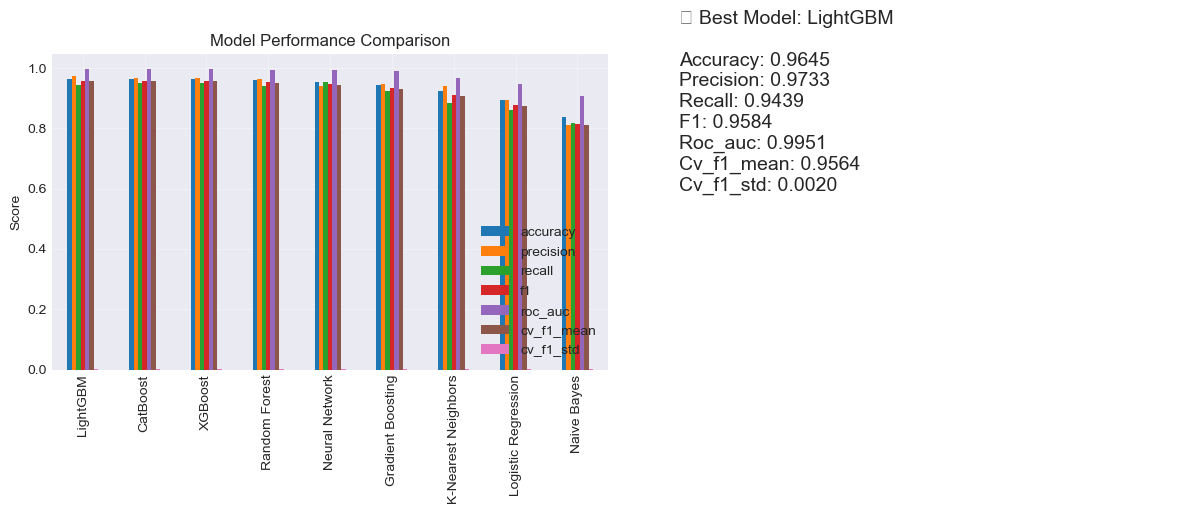

In [37]:
# Display results comparison
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('f1', ascending=False)

# Visualize results
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar plot of metrics
results_df.plot(kind='bar', ax=axes[0])
axes[0].set_title('Model Performance Comparison')
axes[0].set_ylabel('Score')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

# Best model details
best_model_name = results_df.index[0]
best_scores = results_df.iloc[0]

axes[1].axis('off')
text = f"🏆 Best Model: {best_model_name}\n\n"
for metric, score in best_scores.items():
    text += f"{metric.capitalize()}: {score:.4f}\n"

axes[1].text(0.1, 0.5, text, fontsize=14, transform=axes[1].transAxes)

plt.tight_layout()
plt.show()

## 6. Best Model Selection and Fine-tuning

In [38]:
# Select best model
best_model_name = results_df.index[0]
best_model = models[best_model_name]

print(f"🏆 Best model selected: {best_model_name}")

# Cross-validation
cv_scores = cross_val_score(best_model, X_train_scaled, y_train, cv=5, scoring='f1')
print(f"\nCross-validation F1 scores: {cv_scores}")
print(f"Mean CV Score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

🏆 Best model selected: LightGBM

Cross-validation F1 scores: [0.95607199 0.95912038 0.95451969 0.95825078 0.95384834]
Mean CV Score: 0.9564 (+/- 0.0041)


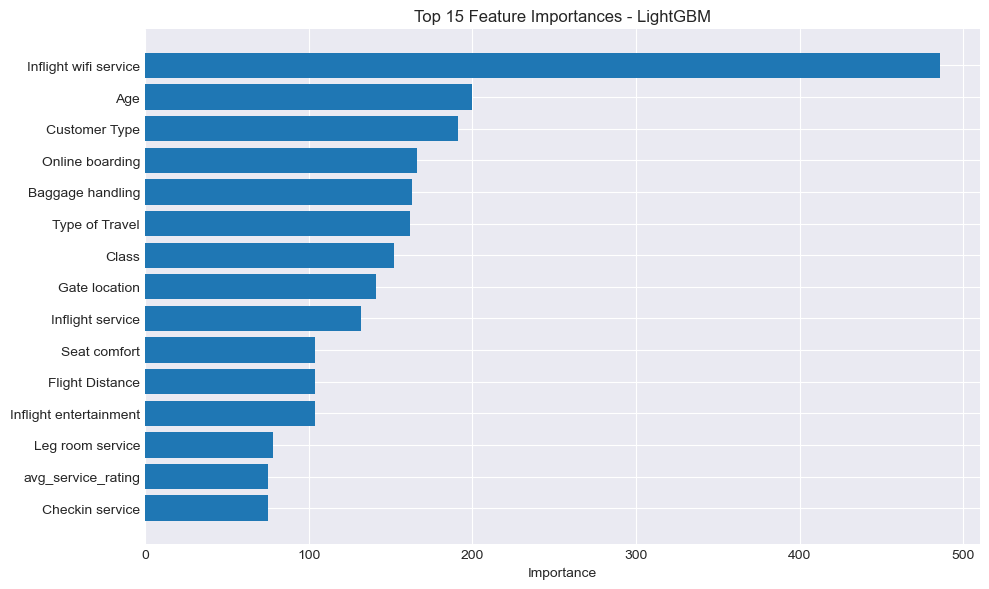


📊 Top 5 Most Important Features:
                  feature  importance
6   Inflight wifi service         486
2                     Age         200
1           Customer Type         191
11        Online boarding         166
16       Baggage handling         163


In [39]:
# Feature importance (if available)
if hasattr(best_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'feature': feature_cols,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    # Plot top 15 features
    plt.figure(figsize=(10, 6))
    top_features = feature_importance.head(15)
    plt.barh(top_features['feature'], top_features['importance'])
    plt.xlabel('Importance')
    plt.title(f'Top 15 Feature Importances - {best_model_name}')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    print("\n📊 Top 5 Most Important Features:")
    print(feature_importance.head())


## 7. Final Model Training and Predictions

In [40]:
# Train final model on full training data
print("🎯 Training final model on full dataset...")

# Combine train and validation sets
X_full = np.vstack([X_train_scaled, X_val_scaled])
y_full = np.concatenate([y_train, y_val])

# Train final model
final_model = models[best_model_name].__class__(**models[best_model_name].get_params())
final_model.fit(X_full, y_full)

print("✅ Final model trained!")

# Make predictions on test set
test_predictions = final_model.predict(X_test_scaled)
test_probabilities = final_model.predict_proba(X_test_scaled)[:, 1]

print(f"\n📊 Test predictions summary:")
print(f"Satisfied: {(test_predictions == 1).sum()} ({(test_predictions == 1).mean():.1%})")
print(f"Unsatisfied: {(test_predictions == 0).sum()} ({(test_predictions == 0).mean():.1%})")

🎯 Training final model on full dataset...
✅ Final model trained!

📊 Test predictions summary:
Satisfied: 11027 (42.5%)
Unsatisfied: 14949 (57.5%)


## 8. Save Model and Artifacts

In [41]:
# Save model
model_filename = f'models/{best_model_name.lower().replace(" ", "_")}_model.pkl'
with open(model_filename, 'wb') as f:
    pickle.dump(final_model, f)
print(f"✅ Model saved to {model_filename}")

# Save scaler
with open('models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("✅ Scaler saved to models/scaler.pkl")

# Save label encoders
with open('models/label_encoders.pkl', 'wb') as f:
    pickle.dump(label_encoders, f)
print("✅ Label encoders saved")

# Save feature list and model info
model_info = {
    'model_name': best_model_name,
    'feature_columns': feature_cols,
    'categorical_columns': categorical_cols,
    'performance_metrics': results[best_model_name],
    'cv_score_mean': float(cv_scores.mean()),
    'cv_score_std': float(cv_scores.std()),
    'training_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'n_features': len(feature_cols),
    'n_training_samples': len(y_full)
}

with open('models/model_info.json', 'w') as f:
    json.dump(model_info, f, indent=4)
print("✅ Model info saved")

✅ Model saved to models/lightgbm_model.pkl
✅ Scaler saved to models/scaler.pkl
✅ Label encoders saved
✅ Model info saved


In [42]:
# Create submission file
submission = pd.DataFrame({
    'id': test_df['id'] if 'id' in test_df.columns else range(len(test_predictions)),
    'satisfaction': ['satisfied' if pred == 1 else 'neutral or dissatisfied' 
                    for pred in test_predictions],
    'probability': test_probabilities
})

submission.to_csv('results/submission.csv', index=False)
print(f"\n✅ Submission file saved to results/submission.csv")
print(f"   Shape: {submission.shape}")


✅ Submission file saved to results/submission.csv
   Shape: (25976, 3)


## 9. Model Deployment Function

In [46]:
def predict_satisfaction(passenger_data):
    if isinstance(passenger_data, dict):
        df = pd.DataFrame([passenger_data])
    else:
        df = passenger_data.copy()

    # Feature engineering
    df = create_features(df)

    # Select model features
    df_features = df[feature_cols].copy()

    # Encode categorical variables
    for col, le in label_encoders.items():
        if col in df_features.columns:
            df_features[col] = df_features[col].apply(
                lambda x: le.transform([x])[0] if x in le.classes_ else le.transform(['Unknown'])[0]
            )

    # Scale
    df_scaled = scaler.transform(df_features)

    # Predict
    prediction = final_model.predict(df_scaled)
    probability = final_model.predict_proba(df_scaled)[:, 1]

    return {
        'prediction': 'satisfied' if prediction[0] == 1 else 'unsatisfied',
        'probability': float(probability[0]),
        'confidence': 'high' if probability[0] > 0.8 or probability[0] < 0.2 else 'medium'
    }


# DURANTE O TREINAMENTO - adicionar isso ao final do label encoding:
for col, le in label_encoders.items():
    if 'Unknown' not in le.classes_:
        le.classes_ = np.append(le.classes_, 'Unknown')


# Exemplo
example_passenger = {
    'Gender': 'Male',
    'Customer Type': 'Loyal Customer',
    'Age': 35,
    'Type of Travel': 'Business travel',
    'Class': 'Business',
    'Flight Distance': 1500,
    'Inflight wifi service': 4,
    'Departure/Arrival time convenient': 4,
    'Ease of Online booking': 5,
    'Gate location': 3,
    'Food and drink': 4,
    'Online boarding': 5,
    'Seat comfort': 4,
    'Inflight entertainment': 4,
    'On-board service': 5,
    'Leg room service': 4,
    'Baggage handling': 5,
    'Checkin service': 4,
    'Inflight service': 5,
    'Cleanliness': 5,
    'Departure Delay in Minutes': 0,
    'Arrival Delay in Minutes': 0
}

result = predict_satisfaction(example_passenger)
print("\n🔮 Example Prediction:")
print(f"Prediction: {result['prediction']}")
print(f"Probability: {result['probability']:.2%}")
print(f"Confidence: {result['confidence']}")

📊 Creating features from 9 service columns...
✈️ Creating delay features...
👤 Creating age features...
📏 Creating distance features...
⚠️ Could not create distance_category: Bin labels must be one fewer than the number of bin edges
✅ Created 17 new features

🔮 Example Prediction:
Prediction: satisfied
Probability: 99.72%
Confidence: high


## 10. Summary

In [47]:
print("\n" + "="*50)
print("🎉 PIPELINE COMPLETE!")
print("="*50)
print(f"\n📊 Best Model: {best_model_name}")
print(f"🎯 Validation Performance:")
for metric, score in results[best_model_name].items():
    print(f"   {metric}: {score:.4f}")
print(f"\n📁 Files saved:")
print(f"   - Model: {model_filename}")
print(f"   - Scaler: models/scaler.pkl")
print(f"   - Encoders: models/label_encoders.pkl")
print(f"   - Model Info: models/model_info.json")
print(f"   - Predictions: results/submission.csv")
print("\n✅ Ready for deployment!")


🎉 PIPELINE COMPLETE!

📊 Best Model: LightGBM
🎯 Validation Performance:
   accuracy: 0.9645
   precision: 0.9733
   recall: 0.9439
   f1: 0.9584
   roc_auc: 0.9951
   cv_f1_mean: 0.9564
   cv_f1_std: 0.0020

📁 Files saved:
   - Model: models/lightgbm_model.pkl
   - Scaler: models/scaler.pkl
   - Encoders: models/label_encoders.pkl
   - Model Info: models/model_info.json
   - Predictions: results/submission.csv

✅ Ready for deployment!
